## TASK 6 — Logistic Regression (Up vs Down)

In [1]:
# import libraries
import pandas as pd, yfinance as yf

# select assets and benchmark
TICKER = ["NVDA", "AMD", "INTC"]
BENCH  = ["QQQ"] 
TICKER = TICKER + BENCH

# 3 year period
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(months=36)

# download adjusted close prices
df = yf.download(TICKER, start=start, end=end, interval="1d", auto_adjust=True)[["Close"]]

# flatten column names if multi-index
# i am not sure why the template appends an extra index on the columns
df.columns = [col if isinstance(col, str) else col[1] for col in df.columns]

# reset index to make Date a column
df = df.reset_index()

# sort values by date
df = df.sort_values("Date")

# forward fill and drop any NAs
df = df.ffill().dropna()

# compute returns
df_returns = df[TICKER].pct_change().rename(columns=lambda x: x+ "_Return")

# align return columns to match df
price_cols = df.columns[1:]
df_returns = df_returns[[col + "_Return" for col in price_cols]]

# concatting two datas
df = pd.concat([df, df_returns], axis=1)

# fill returns of the first row to 0
df.fillna(0, inplace=True)

# convert necessary variables to numeric
# consumes a lot of time despite values being numeric already
variables = TICKER + [t + "_Return" for t in TICKER]
for v in variables:
    df[v] = pd.to_numeric(df[v], errors='coerce')

# save files
df.to_csv("prices_clean.csv", index=False)

# ==============================
# TRANSFORMING QUANTITATIVE DATA
# ==============================

# compress wide-format returns into long format
long_df = df.melt(id_vars="Date", value_vars=[t + "_Return" for t in TICKER], var_name="Ticker", value_name="Return")

# clean ticker names
long_df["Ticker"] = long_df["Ticker"].str.replace("_Return", "")

# convert ticker to categorical variables
long_df["Ticker"] = long_df["Ticker"].astype("category")

# save files
long_df.to_csv("returns_long_format.csv", index=False)

[*********************100%***********************]  4 of 4 completed


In [2]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix

df = pd.read_csv("prices_clean.csv", parse_dates=["Date"]).sort_values("Date")

def logi_regress(ticker):
    df["Return"] = df[f"{ticker}_Return"]

    # construct outcome and lag predictor
    df["Up"] = (df["Return"] > 0).astype(int)
    df["Lag1"] = df["Return"].shift(1)

    # optional: add a macro predictor
    df["Macro"] = df["QQQ_Return"].shift(1)

    # drop missing values
    d = df.dropna(subset=["Up", "Lag1", "Macro"]) # optional macro

    # define predictors
    X = sm.add_constant(d[["Lag1", "Macro"]]) # optional macro
    y = d["Up"]

    # fit logistic regression
    logit = sm.Logit(y, X).fit(disp=False)
    print(logit.summary())

    return [logit, X, y]

def extra_info(logit, X, y):
    # predictions
    pred = (logit.predict(X) >= 0.5).astype(int)

    # confusion matrix
    cm = confusion_matrix(y, pred)
    print("Confusion matrix:\n", cm)

    # accuracy
    acc = (pred == y).mean()
    print("Accuracy: ", round(float(acc), 3))

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def roc(ticker, logit, X, y):
    # predicted probabilities from the model
    pred_prob = logit.predict(X)
    
    # compute ROC metrics
    fpr, tpr, thresholds = roc_curve(y, pred_prob)
    auc = roc_auc_score(y, pred_prob)
    
    # plot ROC curve
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')  # diagonal line for random guess
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {ticker}")
    plt.legend()
    plt.show()

### NVDA

In [4]:
logit = logi_regress(TICKER[0])

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                  751
Model:                          Logit   Df Residuals:                      748
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:               0.0005801
Time:                        19:10:05   Log-Likelihood:                -516.50
converged:                       True   LL-Null:                       -516.80
Covariance Type:            nonrobust   LLR p-value:                    0.7410
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2010      0.074      2.721      0.007       0.056       0.346
Lag1           1.8447      3.471      0.532      0.595      -4.957       8.647
Macro         -6.6908      8.694     -0.770      0.4

In [5]:
extra_info(logit[0], logit[1], logit[2])

Confusion matrix:
 [[  1 337]
 [  0 413]]
Accuracy:  0.551


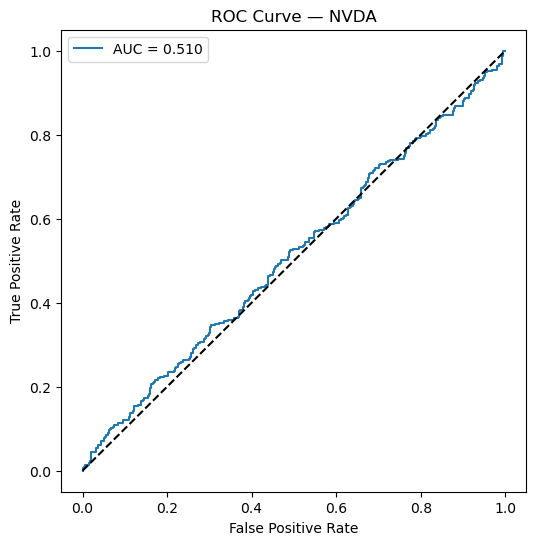

In [6]:
roc(TICKER[0], logit[0], logit[1], logit[2])

### AMD

In [7]:
logit = logi_regress(TICKER[1])

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                  751
Model:                          Logit   Df Residuals:                      748
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                0.002208
Time:                        19:10:19   Log-Likelihood:                -519.29
converged:                       True   LL-Null:                       -520.44
Covariance Type:            nonrobust   LLR p-value:                    0.3169
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0402      0.073      0.548      0.584      -0.104       0.184
Lag1           3.6579      3.127      1.170      0.242      -2.471       9.787
Macro        -11.9302      7.972     -1.497      0.1

In [8]:
extra_info(logit[0], logit[1], logit[2])

Confusion matrix:
 [[138 231]
 [132 250]]
Accuracy:  0.517


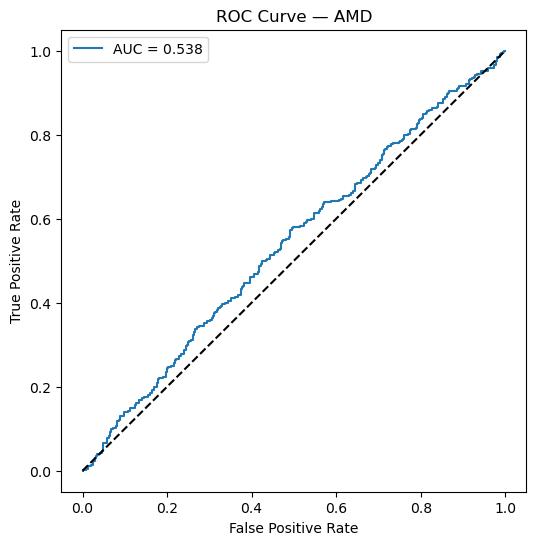

In [9]:
roc(TICKER[1], logit[0], logit[1], logit[2])

### INTC

In [10]:
logit = logi_regress(TICKER[2])

                           Logit Regression Results                           
Dep. Variable:                     Up   No. Observations:                  751
Model:                          Logit   Df Residuals:                      748
Method:                           MLE   Df Model:                            2
Date:                Sun, 16 Nov 2025   Pseudo R-squ.:                0.001790
Time:                        19:10:23   Log-Likelihood:                -519.62
converged:                       True   LL-Null:                       -520.55
Covariance Type:            nonrobust   LLR p-value:                    0.3939
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0119      0.073      0.162      0.872      -0.132       0.156
Lag1           3.4847      2.638      1.321      0.187      -1.686       8.655
Macro         -6.0328      6.593     -0.915      0.3

In [11]:
extra_info(logit[0], logit[1], logit[2])

Confusion matrix:
 [[196 178]
 [165 212]]
Accuracy:  0.543


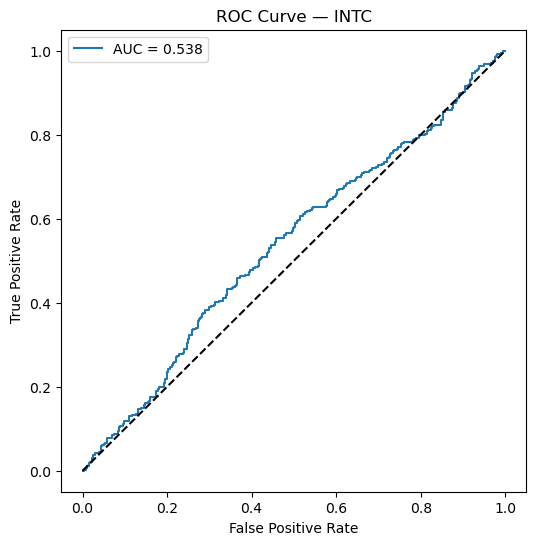

In [12]:
roc(TICKER[2], logit[0], logit[1], logit[2])